In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file=r'C:\Users\kkmal\venv\Customer_Churn_Prediction\notebooks\feature_transformed_telecom.csv'

df=pd.read_csv(file)

In [22]:
df['TotalCharges'] = df['MonthlyCharges'] * df['tenure']

In [23]:
df[['StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'has_partner',
       'has_dependents', 'has_phoneservice']]

,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,has_partner,has_dependents,has_phoneservice
0,-1,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,0,0
1,-1,One year,No,Mailed check,56.95,1936.30,No,0,0,1
2,-1,Month-to-month,Yes,Mailed check,53.85,107.70,Yes,0,0,1
3,-1,One year,No,Bank transfer (automatic),42.30,1903.50,No,0,0,0
4,-1,Month-to-month,Yes,Electronic check,70.70,141.40,Yes,0,0,1
...,...,...,...,...,...,...,...,...,...,...
7038,1,One year,Yes,Mailed check,84.80,2035.20,No,1,1,1
7039,1,One year,Yes,Credit card (automatic),103.20,7430.40,No,1,1,1
7040,-1,Month-to-month,Yes,Electronic check,29.60,325.60,No,1,1,0
7041,-1,Month-to-month,Yes,Mailed check,74.40,297.60,Yes,1,0,1


In [24]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first',handle_unknown='ignore')
categorical_cols = ['Contract', 'PaperlessBilling', 'PaymentMethod']
encoded_data = ohe.fit_transform(df[categorical_cols]).toarray()
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(categorical_cols))
df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1,)

df=df.drop(columns=['Unnamed: 0'])

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   OnlineSecurity                         7043 non-null   int64  
 4   OnlineBackup                           7043 non-null   int64  
 5   DeviceProtection                       7043 non-null   int64  
 6   TechSupport                            7043 non-null   int64  
 7   StreamingTV                            7043 non-null   int64  
 8   StreamingMovies                        7043 non-null   int64  
 9   MonthlyCharges                         7043 non-null   float64
 10  TotalCharges                           7043 non-null   float64
 11  Churn          

In [26]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Churn'])
y=df['Churn'].map({'No': 0, 'Yes': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [28]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5282, 27), (5282,), (1761, 27), (1761,))

In [29]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [30]:
import numpy as np
# Assuming y_train is a pandas Series or numpy array
# Calculate scale_pos_weight for XGBoost: (count of negative examples / count of positive examples)
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

models_configuration = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "Ridge Classifier": {
        "model": RidgeClassifier(class_weight="balanced"),
        "params": {
            "alpha": [0.1, 1.0, 10.0]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(class_weight="balanced"),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced"),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 10, 20]
        }
    },
    "Gradient Boosting": {
        # GradientBoostingClassifier doesn't have class_weight, 
        # so we rely on subsampling or tuning, OR use HistGradientBoostingClassifier which does.
        "model": GradientBoostingClassifier(), 
        "params": {
            "learning_rate": [0.01, 0.1, 0.2],
            "n_estimators": [50, 100, 200]
        }
    },
    "XGBoost": {
        # scale_pos_weight controls the balance of positive/negative weights
        "model": XGBClassifier(eval_metric="logloss", scale_pos_weight=ratio),
        "params": {
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [3, 5, 7],
            "n_estimators": [50, 100, 200]
        }
    },
    "SVC": {
        "model": SVC(class_weight="balanced"),
        "params": {
            "C": [0.1, 1.0, 10.0],
            "kernel": ["rbf", "linear"]
        }
    }
}

In [31]:
'''
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to your TRAINING data (never the test data!)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Now, you can use your original loop from the previous answer, 
# just pass X_train_balanced and y_train_balanced into clf.fit()

from sklearn.model_selection import GridSearchCV


best_models = {}

for model_name, config in models_configuration.items():
    print(f"Tuning {model_name}...")

    clf = GridSearchCV(config["model"], config["params"], cv=5, scoring="roc_auc", n_jobs=-1)
    clf.fit(X_train_balanced, y_train_balanced)
    
    # Save the best model and score
    best_models[model_name] = {
        "best_model": clf.best_estimator_,
        "best_score": clf.best_score_,
        "best_params": clf.best_params_
    }
    
    print(f"Best Score: {clf.best_score_:.4f}\n")
'''

'\nfrom imblearn.over_sampling import SMOTE\n\n# Apply SMOTE only to your TRAINING data (never the test data!)\nsmote = SMOTE(random_state=42)\nX_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)\n\n# Now, you can use your original loop from the previous answer, \n# just pass X_train_balanced and y_train_balanced into clf.fit()\n\nfrom sklearn.model_selection import GridSearchCV\n\n\nbest_models = {}\n\nfor model_name, config in models_configuration.items():\n    print(f"Tuning {model_name}...")\n\n    clf = GridSearchCV(config["model"], config["params"], cv=5, scoring="roc_auc", n_jobs=-1)\n    clf.fit(X_train_balanced, y_train_balanced)\n\n    # Save the best model and score\n    best_models[model_name] = {\n        "best_model": clf.best_estimator_,\n        "best_score": clf.best_score_,\n        "best_params": clf.best_params_\n    }\n\n    print(f"Best Score: {clf.best_score_:.4f}\n")\n'

In [33]:
'''best_models['XGBoost']'''

"best_models['XGBoost']"

In [43]:
ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))

xgc=XGBClassifier(eval_metric="logloss", scale_pos_weight=ratio,learning_rate=0.1, max_depth=3, n_estimators=50)
xgc.fit(X_train, y_train)
y_pred_proba=xgc.predict_proba(X_test)
y_pred=xgc.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1294
           1       0.52      0.83      0.64       467

    accuracy                           0.75      1761
   macro avg       0.72      0.78      0.73      1761
weighted avg       0.81      0.75      0.77      1761



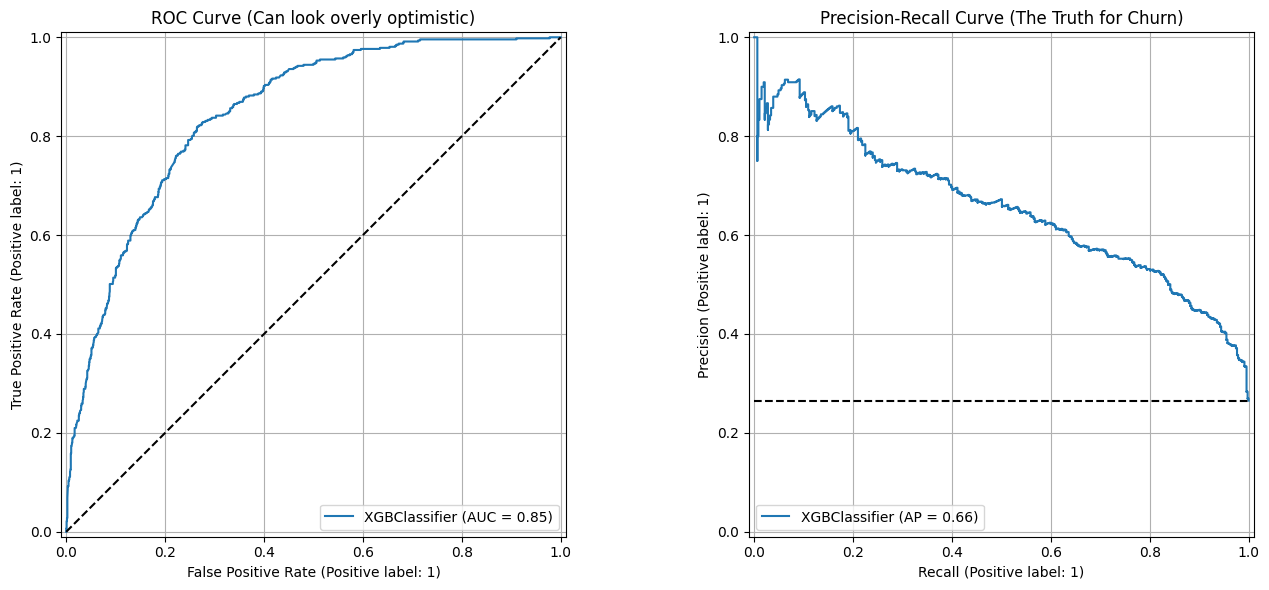

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Set up a 1x2 plotting area
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Plot ROC Curve on the first axis
RocCurveDisplay.from_estimator(xgc, X_test, y_test, ax=ax1)
ax1.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
ax1.set_title('ROC Curve (Can look overly optimistic)')
ax1.grid(True)

# 2. Plot Precision-Recall Curve on the second axis
PrecisionRecallDisplay.from_estimator(xgc, X_test, y_test, ax=ax2)
# Baseline for PR curve is the percentage of positive cases (467 / 1761)
baseline = 467 / 1761
ax2.plot([0, 1], [baseline, baseline], 'k--', label=f'Random (AP = {baseline:.2f})')
ax2.set_title('Precision-Recall Curve (The Truth for Churn)')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [41]:
'''
import pickle

pickle.dump(xgc,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\xgboost_model.pkl','wb'))
pickle.dump(scaler,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\scaler.pkl','wb'))
pickle.dump(ohe,open(r'C:\Users\kkmal\venv\Customer_Churn_Prediction\models\ohe.pkl','wb'))
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 41-42: truncated \UXXXXXXXX escape (2697090981.py, line 1)

In [42]:
# CLV from actual spend data (imputed where missing)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)

clv = df.loc[X_test.index, 'TotalCharges'].values

# CLV-weighted priority score
churn_proba = xgc.predict_proba(X_test)[:, 1]

priority_score = churn_proba * clv

results = pd.DataFrame({
    'churn_probability': churn_proba,
    'CLV': clv,
    'priority_score': priority_score,
    'actual': y_test.values
}).sort_values('priority_score', ascending=False)

print(results.head(10))

      churn_probability      CLV  priority_score  actual
1367           0.588751  7423.50     4370.596722       0
168            0.677578  6369.00     4315.497143       0
746            0.617882  6960.10     4300.518941       0
1742           0.612003  6793.80     4157.827794       0
1018           0.732366  5658.80     4144.314551       0
761            0.625729  6520.50     4080.064549       0
1272           0.617882  6569.65     4059.267002       0
1629           0.666106  5988.00     3988.641571       0
971            0.577082  6862.05     3959.965798       1
32             0.550275  7072.00     3891.544996       0


C:\Users\kkmal\AppData\Local\Temp\ipykernel_19572\2814513437.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)
